# Composite Index: Cheapest & Coldest Country to Visit
---

# Cheapest and Coldest Country Index

This notebook creates a holiday score from **0 to 1** where higher means better for travelers who want destinations that are both **colder** and **more affordable**.

The score uses three pillars:
- **Economy (35%)**: meal, transport, and apartment cost (lower is better)
- **Environment (40%)**: temperature, wind, UV, and weather condition score
- **Risk (25%)**: disaster count, severity, and threat days (lower is better)

All indicators are min-max normalized so they are on the same scale before combining.

| Pillar | Weight | Temperature direction |
|---|---|---|
| Economy | 35 % | — |
| Environment | 40 % | `temperature_celsius` lower = better *(cold — inverted)* |
| Risk | 25 % | — |

**Environment — mixed direction breakdown:**

| Indicator | Direction | Rationale |
|---|---|---|
| `temperature_celsius` | lower = better (inverted) | Colder destinations score higher |
| `wind_kph` | lower = better (inverted) | Strong winds reduce outdoor appeal |
| `uv_index` | lower = better (inverted) | Lower UV reduces exposure risk |
| `condition_score` | higher = better | Better weather conditions score higher |

---

In [16]:
import pandas as pd

# 1) Load combined holiday data
input_path = "Combined_Holiday.csv"
df = pd.read_csv(input_path)

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
display(df.head())

Rows: 170, Columns: 13


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment,temperature_celsius,wind_kph,uv_index,condition_text,condition_category,condition_score,Disaster_Count,Median_Severity,Unique_Days_Under_Threat
0,Afghanistan,3.41,0.22,79.90,18.754247,10.340000,4.694795,sunny,Clear,5,6.0,0.50,22.0
1,Albania,12.48,0.43,186.79,21.625479,9.776438,4.181096,sunny,Clear,5,1.0,0.00,7.0
2,Algeria,6.66,0.21,143.88,22.275068,14.090685,3.846849,partly cloudy,Partly Cloudy,4,5.0,0.25,8.0
3,Andorra,20.17,1.90,811.73,10.402192,9.050137,2.798630,sunny,Clear,5,0.0,0.00,0.0
4,Angola,32.12,0.59,220.39,27.371233,11.057808,6.942192,partly cloudy,Partly Cloudy,4,2.0,1.00,11.0


## 3.2 — Normalise Indicators (Min-Max)

Each indicator is scaled to [0, 1] using min-max normalisation.  
For indicators where **lower = better**, the score is inverted with `1 − normalised_value`.

In [17]:
# 2) Normalize indicators to 0-1 (higher score = better)

def minmax_score(series, lower_is_better=False):
    s = pd.to_numeric(series, errors="coerce")
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.5, index=s.index)
    scaled = (s - s_min) / (s_max - s_min)
    return 1 - scaled if lower_is_better else scaled

indicator_directions = {
    # Economy (lower is better)
    "Mid_range_meal_pp": True,
    "One_way_local_transport_ticket": True,
    "Apartment": True,

    # Environment
    "temperature_celsius": True,
    "wind_kph": True,
    "uv_index": True,
    "condition_score": False,

    # Risk (lower is better)
    "Disaster_Count": True,
    "Median_Severity": True,
    "Unique_Days_Under_Threat": True,
}

available = [c for c in indicator_directions if c in df.columns]
missing = [c for c in indicator_directions if c not in df.columns]

for col in available:
    df[f"score_{col}"] = minmax_score(df[col], lower_is_better=indicator_directions[col])

print("Normalized columns created:", len(available))
if missing:
    print("Missing columns skipped:", missing)

Normalized columns created: 10


## 3.3 Build Final Holiday Index

- pillar scores (Economy, Environment, Risk)
- final weighted Holiday Index using 35% / 40% / 25%

In [18]:
# 3) Build pillar scores and final Holiday Index

economy_cols = [
    "score_Mid_range_meal_pp",
    "score_One_way_local_transport_ticket",
    "score_Apartment",
]
environment_cols = [
    "score_temperature_celsius",
    "score_wind_kph",
    "score_uv_index",
    "score_condition_score",
]
risk_cols = [
    "score_Disaster_Count",
    "score_Median_Severity",
    "score_Unique_Days_Under_Threat",
]

def mean_of_existing(frame, cols):
    cols = [c for c in cols if c in frame.columns]
    if not cols:
        return pd.Series(0.0, index=frame.index)
    return frame[cols].mean(axis=1)

df["Economy_Score"] = mean_of_existing(df, economy_cols)
df["Environment_Score"] = mean_of_existing(df, environment_cols)
df["Risk_Score"] = mean_of_existing(df, risk_cols)

weights = {"Economy_Score": 0.35, "Environment_Score": 0.40, "Risk_Score": 0.25}
df["Holiday_Index"] = sum(df[col] * w for col, w in weights.items())

display(df[["country", "Economy_Score", "Environment_Score", "Risk_Score", "Holiday_Index"]].head())

,country,Economy_Score,Environment_Score,Risk_Score,Holiday_Index
0,Afghanistan,0.987272,0.712398,0.744276,0.816573
1,Albania,0.928483,0.707478,0.982113,0.853489
2,Algeria,0.969286,0.608321,0.851889,0.795551
3,Andorra,0.774354,0.837881,1.000000,0.856176
4,Angola,0.829714,0.518860,0.633632,0.656352


## 3.4 Country Rankings

The top 20 cheapest & coldest countries to visit are as follows:

In [ ]:
# 4) Rank countries and show top 20

top_20 = (
    df.sort_values("Holiday_Index", ascending=False)
      .loc[:, [
          "country",
          "Holiday_Index",
          "Economy_Score",
          "Environment_Score",
          "Risk_Score",
          "temperature_celsius",
          "Mid_range_meal_pp",
      ]]
      .head(20)
      .reset_index(drop=True)
)

display(top_20)

,country,Holiday_Index,Economy_Score,Environment_Score,Risk_Score,temperature_celsius,Mid_range_meal_pp
0,North Korea,0.913023,0.913503,0.858244,1.000000,12.302740,10.24
1,South Korea,0.896076,0.874696,0.849831,1.000000,14.502192,14.79
2,Bolivia,0.893154,0.955723,0.771627,1.000000,18.362740,6.35
3,Venezuela,0.879740,0.899585,0.787212,1.000000,23.288767,16.53
4,El Salvador,0.873545,0.918382,0.798541,0.930779,23.153425,10.72
5,Mexico,0.872010,0.908159,0.883974,0.802259,14.240822,13.60
6,Russia,0.865846,0.880329,0.769329,1.000000,11.468767,19.26
7,Mongolia,0.863564,0.965098,0.885851,0.685758,2.681096,8.76
8,Lithuania,0.860011,0.877075,0.768767,0.982113,11.532877,16.84
9,Hungary,0.856992,0.887572,0.752035,0.982113,15.880274,14.95


Saved: index_cheapest_coldest_country_results.csv


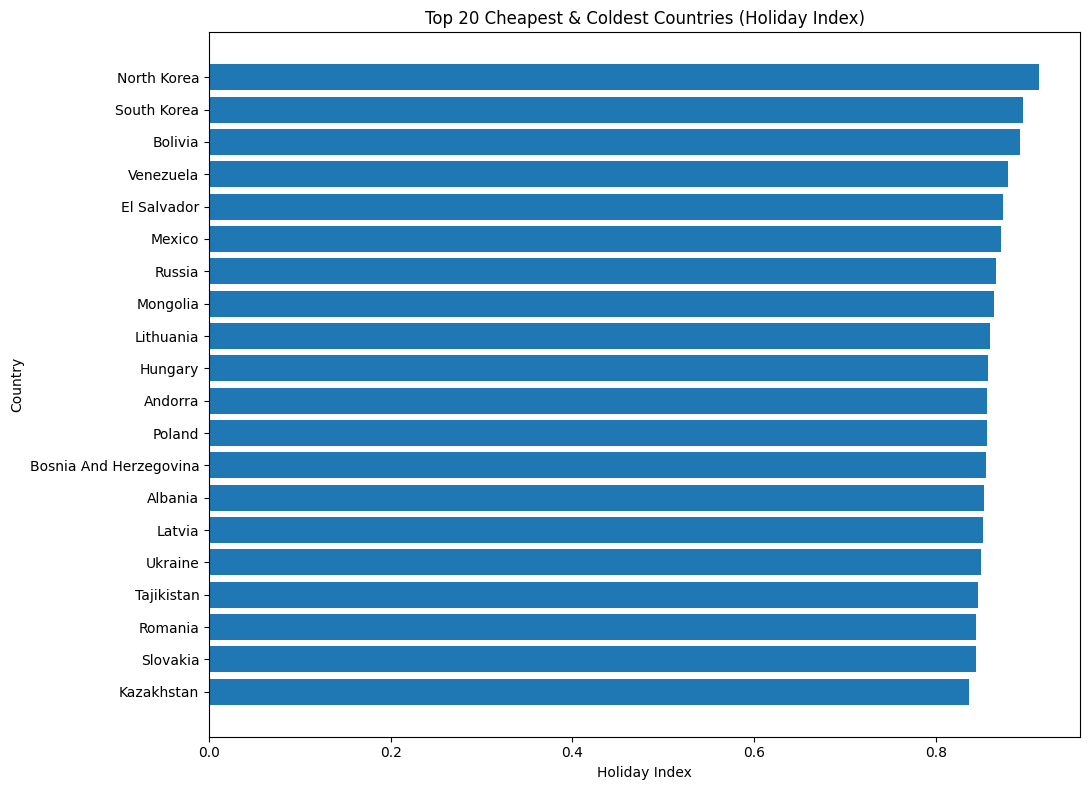

In [20]:
# 5) Graph top 20 countries by Holiday Index
import matplotlib.pyplot as plt

plot_df = top_20.sort_values("Holiday_Index", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df["country"], plot_df["Holiday_Index"])
plt.xlabel("Holiday Index")
plt.ylabel("Country")
plt.title("Top 20 Cheapest & Coldest Countries (Holiday Index)")
plt.tight_layout()
plt.show()

According to the chart, North Korea, South Korea, and Bolivia achieve the highest scores on the cheapest-and-coldest holiday index, suggesting they offer the strongest combination of lower travel costs, colder weather and lowest disaster risk within my dataset.

A number of countries on the list fit that expectation reasonably well, especially destinations such as Russia, Mongolia, and Poland, which are widely associated with cold climates and relatively affordable travel compared with Western Europe. However, some results are less intuitive. Mexico, El Salvador, and Venezuela are typically seen as warm destinations, so their high ranking is likely affected by mountainous regions inflating average cold readings rather than a genuinely cold overall climate.

South Korea, however, stands out as a more complex case. While it does experience cold winters, it is generally considered an expensive country to visit, with high costs for accommodation, transport, and dining relative to much of Asia. It is also situated in a seismically active region and is exposed to typhoons and seasonal flooding, making it more disaster-prone than many of the other countries in the top 20. 

Its high ranking here is therefore likely an artefact of how winter temperatures are averaged across all recorded and how the pillar weigh, rather than a genuine reflection of it being a cheap, cold, and low-risk holiday destination. 

Overall, the index works reasonably well as a basic mix of cold climate, affordability and safety, but it does not fully match what most people would think of as the best cheap cold holiday destinations.